<a href="https://colab.research.google.com/github/Manishagg1406/spam-email-classifier/blob/main/spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📧 Spam Email Classifier
**Stack:** NLTK · scikit-learn · Naive Bayes · Logistic Regression  
**Dataset:** UCI SMS Spam Collection

## 1. Install & Import Dependencies

In [1]:
!pip install -q nltk scikit-learn pandas matplotlib seaborn

import re, pickle, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
print('All imports successful')

All imports successful


## 2. Load Dataset

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
urllib.request.urlretrieve(url, 'smsspamcollection.zip')
with zipfile.ZipFile('smsspamcollection.zip', 'r') as z:
    z.extractall('.')

df = pd.read_csv('SMSSpamCollection', sep='\t', header=None, names=['label', 'text'])
print(f'Shape: {df.shape}')
print(f'\nClass distribution:\n{df["label"].value_counts()}')
print(f'\nSpam %: {df["label"].value_counts(normalize=True)["spam"]*100:.1f}%')
df.head()

Shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam %: 13.4%


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Preprocessing

In [3]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df['clean'] = df['text'].apply(preprocess)
df['label_enc'] = (df['label'] == 'spam').astype(int)

print('Sample preprocessed texts:')
for _, row in df[['text', 'clean', 'label']].head(4).iterrows():
    print(f'  [{row.label.upper()}] {row.text[:60]!r}')
    print(f'         -> {row.clean[:60]!r}\n')

Sample preprocessed texts:
  [HAM] 'Go until jurong point, crazy.. Available only in bugis n gre'
         -> 'go jurong point crazi avail bugi great world la buffet cine '

  [HAM] 'Ok lar... Joking wif u oni...'
         -> 'ok lar joke wif oni'

  [SPAM] 'Free entry in 2 a wkly comp to win FA Cup final tkts 21st Ma'
         -> 'free entri wkli comp win fa cup final tkt st may text fa rec'

  [HAM] 'U dun say so early hor... U c already then say...'
         -> 'dun say earli hor alreadi say'



## 4. Feature Extraction — BoW & TF-IDF

In [4]:
X_raw = df['clean']
y     = df['label_enc']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

bow_vec = CountVectorizer(max_features=5000)
X_train_bow = bow_vec.fit_transform(X_train_raw)
X_test_bow  = bow_vec.transform(X_test_raw)

tfidf_vec = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vec.fit_transform(X_train_raw)
X_test_tfidf  = tfidf_vec.transform(X_test_raw)

print(f'Vocab size (BoW):    {len(bow_vec.vocabulary_):,}')
print(f'Vocab size (TF-IDF): {len(tfidf_vec.vocabulary_):,}')
print(f'Train: {X_train_bow.shape[0]} | Test: {X_test_bow.shape[0]}')

Vocab size (BoW):    5,000
Vocab size (TF-IDF): 5,000
Train: 4457 | Test: 1115


## 5. Model Training

In [5]:
models = {
    'NB + BoW':    (MultinomialNB(),                              X_train_bow,   X_test_bow),
    'NB + TF-IDF': (MultinomialNB(),                              X_train_tfidf, X_test_tfidf),
    'LR + BoW':    (LogisticRegression(max_iter=1000, random_state=42), X_train_bow,   X_test_bow),
    'LR + TF-IDF': (LogisticRegression(max_iter=1000, random_state=42), X_train_tfidf, X_test_tfidf),
}

results = {}
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    results[name] = {
        'model': model, 'preds': preds,
        'acc':  accuracy_score(y_test, preds),
        'prec': precision_score(y_test, preds),
        'rec':  recall_score(y_test, preds),
        'f1':   f1_score(y_test, preds),
    }

print(f'{"Model":<14} {"Acc":>7} {"Prec":>7} {"Rec":>7} {"F1":>7}')
print('-' * 46)
for name, r in results.items():
    print(f'{name:<14} {r["acc"]:>7.4f} {r["prec"]:>7.4f} {r["rec"]:>7.4f} {r["f1"]:>7.4f}')

Model              Acc    Prec     Rec      F1
----------------------------------------------
NB + BoW        0.9776  0.9429  0.8859  0.9135
NB + TF-IDF     0.9650  1.0000  0.7383  0.8494
LR + BoW        0.9839  1.0000  0.8792  0.9357
LR + TF-IDF     0.9677  1.0000  0.7584  0.8626


## 6. Evaluation — Confusion Matrices

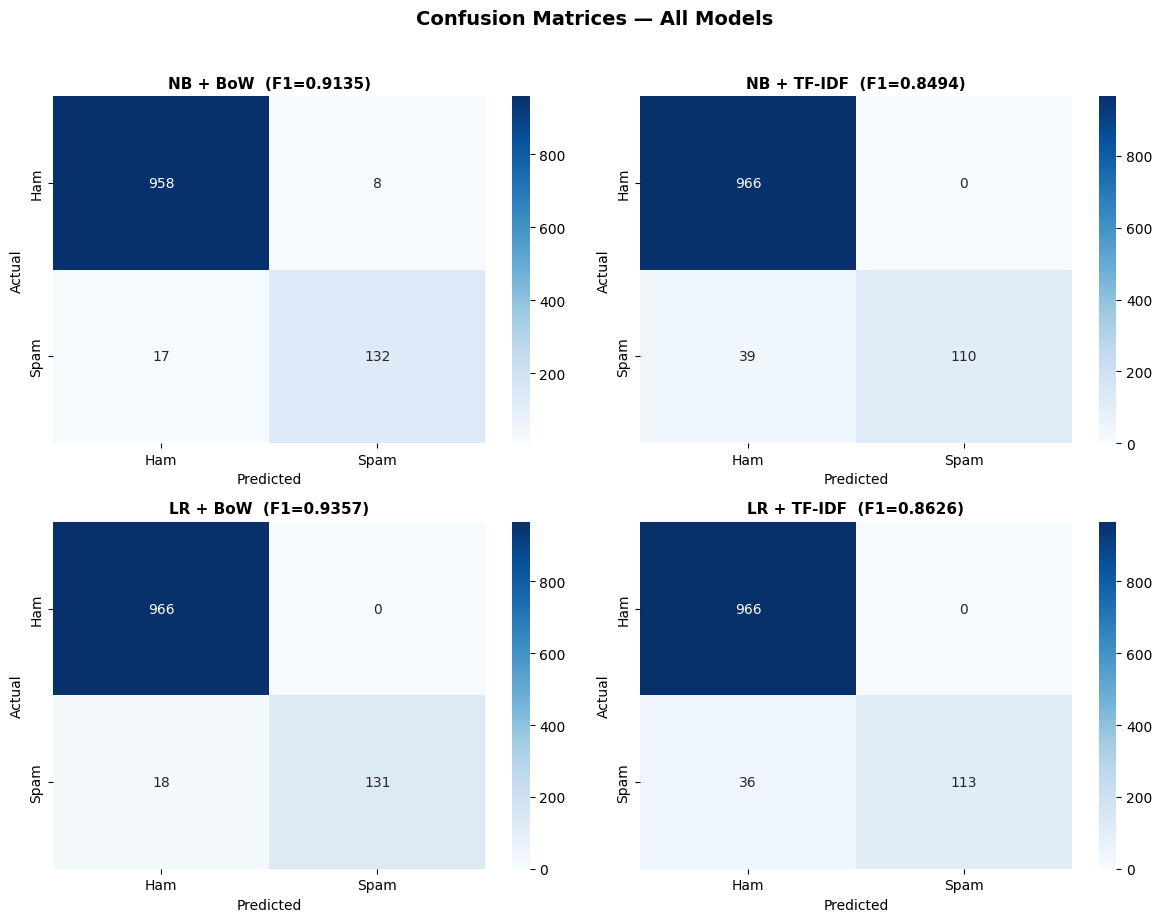


Detailed report (LR + TF-IDF):
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(f'{name}  (F1={r["f1"]:.4f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nDetailed report (LR + TF-IDF):')
print(classification_report(y_test, results['LR + TF-IDF']['preds'], target_names=['Ham', 'Spam']))

## 7. Save Best Model

In [7]:
best_model = results['LR + TF-IDF']['model']
best_vec   = tfidf_vec

with open('spam_model.pkl', 'wb') as f:
    pickle.dump({'model': best_model, 'vectorizer': best_vec}, f)
print('Model saved to spam_model.pkl')

with open('spam_model.pkl', 'rb') as f:
    saved = pickle.load(f)
print('Model reloaded successfully')

Model saved to spam_model.pkl
Model reloaded successfully


## 8. Prediction Function

In [8]:
def predict_spam(text, threshold=0.5):
    clean = preprocess(text)
    vec   = best_vec.transform([clean])
    prob  = best_model.predict_proba(vec)[0][1]
    label = 'SPAM' if prob >= threshold else 'HAM'
    return label, prob, clean

test_messages = [
    'Congratulations! You have won a FREE iPhone. Click here to claim now!!!',
    'Hey, are we still meeting for lunch at 1pm tomorrow?',
    'URGENT: Your account has been compromised. Call 1-800-FREE-CASH immediately!',
    'Can you review the PR I pushed this morning?',
    'Win cash prizes! Txt WIN to 80082 now. No cost.',
]

print(f'{"Message":<55} {"Label":<6} {"P(spam)"}')
print('-' * 75)
for msg in test_messages:
    label, prob, _ = predict_spam(msg)
    print(f'{msg[:54]:<55} {label:<6} {prob:.4f}')

Message                                                 Label  P(spam)
---------------------------------------------------------------------------
Congratulations! You have won a FREE iPhone. Click her  SPAM   0.5356
Hey, are we still meeting for lunch at 1pm tomorrow?    HAM    0.0215
URGENT: Your account has been compromised. Call 1-800-  SPAM   0.6177
Can you review the PR I pushed this morning?            HAM    0.0603
Win cash prizes! Txt WIN to 80082 now. No cost.         SPAM   0.9651


## 9. Interactive Tester

In [9]:
user_input = input('Enter a message to classify (Enter for demo): ').strip()

if not user_input:
    user_input = 'Free entry in 2 a weekly competition to win FA Cup Final tickets!'
    print(f'Demo: {user_input!r}')

label, prob, clean_tokens = predict_spam(user_input)
print(f'\nInput   : {user_input}')
print(f'Cleaned : {clean_tokens}')
print(f'Result  : {label}  (confidence: {prob:.2%})')

Enter a message to classify (Enter for demo): URGENT: Your PayPal account is suspended. Verify now at http://paypal-secure-login.ru or lose access!

Input   : URGENT: Your PayPal account is suspended. Verify now at http://paypal-secure-login.ru or lose access!
Cleaned : urgent paypal account suspend verifi httppaypalsecureloginru lose access
Result  : HAM  (confidence: 22.49%)
